In [8]:
!pip install -q umap-learn==0.5.6
!pip install -q --upgrade pip setuptools wheel
!pip install -q Cython numpy
!pip install -q gensim

In [9]:
import gensim
import os
import pandas as pd
import re
from collections import Counter
import numpy as np
from gensim.models import Word2Vec
import multiprocessing
from gensim.models import FastText
from typing import List, Tuple
from collections import defaultdict
import umap
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
DATA_CSV = "/content/processed_v2.csv"
TRAIN_IDS = "/content/splits_train_ids.txt"
VAL_IDS = "/content/splits_val_ids.txt"
TEST_IDS = "/content/splits_test_ids.txt"

df = pd.read_csv(DATA_CSV)
df = df.rename(columns={"processed_text": "text"})

df = df[df["label"].isin(["Real", "Fake"])].reset_index(drop=True)
df["text_id"] = range(len(df))
df["label_num"] = df["label"].map({"Real":0, "Fake":1})

train_ids = pd.read_csv(TRAIN_IDS, header=None)[0].tolist()
val_ids = pd.read_csv(VAL_IDS, header=None)[0].tolist()
test_ids = pd.read_csv(TEST_IDS, header=None)[0].tolist()

train_df = df[df["text_id"].isin(train_ids)].reset_index(drop=True)
val_df = df[df["text_id"].isin(val_ids)].reset_index(drop=True)
test_df = df[df["text_id"].isin(test_ids)].reset_index(drop=True)

print("All labeled texts:", len(df))
print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

All labeled texts: 7860
Train: 6288 Val: 786 Test: 786


In [12]:
# очищення і токенізація
def simple_tokenize(text):
    if not isinstance(text, str):
        return []
    toks = [t for t in text.split() if t]
    return toks

def normalize_tokens(tokens):
    cleaned = []
    for t in tokens:
        # привести до нижнього регістру
        t = t.lower()
        # видалити крайні лапки/зайву пунктуацію
        t = re.sub(r'^[\W_]+|[\W_]+$', '', t)
        # видалити токени, що містять цифри або дуже короткі
        if not t or re.search(r'\d', t) or len(t) < 3:
            continue
        cleaned.append(t)
    return cleaned

df["tokens"] = df["text"].apply(simple_tokenize)
df['tokens'] = df['tokens'].apply(normalize_tokens)
df = df[df["tokens"].map(len) > 0].reset_index(drop=True)

# спліти
train_df = df[df["text_id"].isin(train_ids)].reset_index(drop=True)
val_df = df[df["text_id"].isin(val_ids)].reset_index(drop=True)
test_df = df[df["text_id"].isin(test_ids)].reset_index(drop=True)

def corpus_stats(dframe):
    n_docs = len(dframe)
    n_tokens = dframe["tokens"].map(len).sum()
    avg_len = dframe["tokens"].map(len).mean() if n_docs>0 else 0
    return {"n_docs": n_docs, "n_tokens": int(n_tokens), "avg_len": float(avg_len)}

print("Corpus (all labeled):", corpus_stats(df))
print("Train:", corpus_stats(train_df))
print("Val:", corpus_stats(val_df))
print("Test:", corpus_stats(test_df))

# найчастіші токени
all_tokens = [tok for toks in df["tokens"] for tok in toks]
freq = Counter(all_tokens)
print("Vocab size:", len(freq))
print("Top 20 tokens:", freq.most_common(20))

Corpus (all labeled): {'n_docs': 7860, 'n_tokens': 1064027, 'avg_len': 135.37239185750636}
Train: {'n_docs': 6288, 'n_tokens': 866964, 'avg_len': 137.8759541984733}
Val: {'n_docs': 786, 'n_tokens': 95896, 'avg_len': 122.00508905852418}
Test: {'n_docs': 786, 'n_tokens': 101167, 'avg_len': 128.71119592875317}
Vocab size: 109274
Top 20 tokens: [('про', 9683), ('для', 6301), ('україни', 6021), ('від', 4585), ('він', 4479), ('також', 4323), ('які', 4139), ('року', 3588), ('його', 3378), ('україні', 3346), ('під', 3082), ('але', 2970), ('вони', 2647), ('час', 2637), ('росії', 2509), ('сша', 2464), ('щоб', 2456), ('після', 2416), ('буде', 2174), ('який', 2134)]


In [13]:
for i, row in df.sample(5, random_state=42).iterrows():
    print("ID:", row["text_id"], "Label:", row["label"])
    print("Text (first 300 chars):", row["text"][:300])
    print("Tokens (first 30):", row["tokens"][:30])
    print("-"*80)

ID: 7095 Label: Real
Text (first 300 chars): про це заявив речник повітряних сил зсу юрій ігнат в етері телемарафону. “ми маємо за повномасштабне вторгнення ракет усіх типів (запущених - ред.) по україні понад 7500. це усіх типів - авіаційні ракети, зенітні ракети с-300, крилаті ракети, балістичні - запущена така кількість”, - заявив ігнат. ре
Tokens (first 30): ['про', 'заявив', 'речник', 'повітряних', 'сил', 'зсу', 'юрій', 'ігнат', 'етері', 'телемарафону', 'маємо', 'повномасштабне', 'вторгнення', 'ракет', 'усіх', 'типів', 'запущених', 'ред', 'україні', 'понад', 'усіх', 'типів', 'авіаційні', 'ракети', 'зенітні', 'ракети', 'крилаті', 'ракети', 'балістичні', 'запущена']
--------------------------------------------------------------------------------
ID: 1405 Label: Fake
Text (first 300 chars): повернення викрадених росією дітей: на мальті домовились про міжнародну коаліцію ініціативу делегації канади об'єднати зусилля багатьох країн для повернення українських дітей на батьківщину підтри

In [32]:
sentences = train_df["tokens"].tolist()

w2v_params = {
    "vector_size": 200,
    "window": 5,
    "min_count": 5,        # мінімум, щоб уникнути дуже рідкісних шумних токенів
    "sg": 1,               # skip-gram, краще для рідкісних слів
    "workers": max(1, multiprocessing.cpu_count()-1),
    "epochs": 8
}

w2v_model = Word2Vec(sentences=sentences, **w2v_params)
w2v_model.save("/content/word2vec_lab9.model")
print("Word2Vec trained and saved. Vocab size:", len(w2v_model.wv))

Word2Vec trained and saved. Vocab size: 22392


In [33]:
ft_params = {
    "vector_size": 200,
    "window": 5,
    "min_count": 5,
    "sg": 1,
    "workers": max(1, multiprocessing.cpu_count()-1),
    "epochs": 8
}

ft_model = FastText(sentences=sentences, **ft_params)
ft_model.save("/content/fasttext_lab9.model")
print("FastText trained and saved. Vocab size:", len(ft_model.wv))

FastText trained and saved. Vocab size: 22392


In [34]:
def get_neighbors(model, word: str, topn: int = 10) -> List[Tuple[str, float]]:
    try:
        return model.wv.most_similar(word, topn=topn)
    except KeyError:
        # OOV handling: for FastText gensim can still produce vector; for Word2Vec it raises KeyError
        if hasattr(model, "wv") and hasattr(model.wv, "get_vector"):
            try:
                vec = model.wv.get_vector(word)
                # compute similarities manually
                sims = model.wv.similar_by_vector(vec, topn=topn)
                return sims
            except Exception:
                return []
        return []

def neighbors_to_str(neis):
    return "; ".join([f"{w} ({sim:.3f})" for w, sim in neis])

# Save a summary table
results_rows = []

def add_result_row(word, wtype, w2v_nei, ft_nei, useful, comment):
    results_rows.append({
        "Word": word,
        "Type": wtype,
        "Word2Vec": neighbors_to_str(w2v_nei),
        "FastText": neighbors_to_str(ft_nei),
        "Useful": useful,
        "Comment": comment
    })

def save_results_csv(path="/content/embeddings_neighbors_summary.csv"):
    pd.DataFrame(results_rows).to_csv(path, index=False)
    print("Saved summary to", path)

In [35]:
control_words = [
    "влада",        # frequent general
    "поранення",    # domain / topical
    "фейк",         # domain / label word
    "підтверджено", # morphological variants
    "сша",          # named entity
    "вакцина",      # domain
    "розслідування",# less frequent domain
    "напад",        # frequent
    "іпсо",         # rare domain
    "коментар",     # frequent
    "раптово"       # noisy / spelling variants
]

for w in control_words:
    w2v_nei = get_neighbors(w2v_model, w, topn=10)
    ft_nei = get_neighbors(ft_model, w, topn=10)
    print(f"=== {w} ===")
    print("Word2Vec:", neighbors_to_str(w2v_nei))
    print("FastText:", neighbors_to_str(ft_nei))
    print()
    wtype = "domain" if w in ["коронавірус","вакцина","розслідування","підробка","фейк"] else ("frequent" if freq.get(w,0)>100 else "rare")
    add_result_row(w, wtype, w2v_nei, ft_nei, "", "")

=== влада ===
Word2Vec: місцева (0.677); українська (0.595); ймовірну (0.587); сторона (0.586); окупаційна (0.573); фінська (0.559); заявила (0.546); стріляниною (0.545); дозволила (0.542); звинуватила (0.535)
FastText: влад (0.807); владу (0.721); владі (0.690); владімір (0.681); власне (0.678); болгарська (0.676); путінська (0.675); хотінська (0.674); радянська (0.672); либідська (0.669)

=== поранення ===
Word2Vec: уламкові (0.818); осколкові (0.817); осколкове (0.786); важкому (0.779); контузію (0.777); дістали (0.775); дістала (0.773); семеро (0.767); поліцейський (0.766); вибухову (0.764)
FastText: поранень (0.844); пораненнями (0.824); поранені (0.817); танення (0.798); поранено (0.795); поранена (0.792); загорання (0.769); ушкодження (0.761); пораненого (0.749); восьмеро (0.748)

=== фейк ===
Word2Vec: розповсюджує (0.913); символікою (0.834); ісламська (0.831); гасло (0.820); іділ (0.816); відкидає (0.813); допису (0.811); звільненням (0.810); belliпgcat (0.810); убити (0.809)

In [36]:
domain_terms = ["фейк", "підтвердження", "інформація", "верифікувати", "джерело"]

for term in domain_terms:
    w2v_nei = get_neighbors(w2v_model, term, topn=10)
    ft_nei = get_neighbors(ft_model, term, topn=10)
    print(f"--- Domain term: {term} ---")
    print("Word2Vec:", neighbors_to_str(w2v_nei))
    print("FastText:", neighbors_to_str(ft_nei))
    print()
    add_result_row(term, "domain", w2v_nei, ft_nei, "", "")

--- Domain term: фейк ---
Word2Vec: розповсюджує (0.913); символікою (0.834); ісламська (0.831); гасло (0.820); іділ (0.816); відкидає (0.813); допису (0.811); звільненням (0.810); belliпgcat (0.810); убити (0.809)
FastText: газеті (0.820); папи (0.817); медведєв (0.814); каллас (0.814); шнайдер (0.806); акаунті (0.805); шольцу (0.797); азербайджан (0.795); ютуб-каналі (0.794); пєсков (0.793)

--- Domain term: підтвердження ---
Word2Vec: довідки (0.803); батьківства (0.787); займатиметься (0.764); направлення (0.763); джерелами (0.762); виникнення (0.762); підстав (0.760); військкоматах (0.756); списків (0.755); вирішується (0.754)
FastText: твердження (0.918); підтвердженням (0.904); затвердження (0.879); підтверджень (0.868); підтверджено (0.832); відрядження (0.814); уточнення (0.809); виверження (0.804); налагодження (0.794); заощадження (0.793)

--- Domain term: інформація ---
Word2Vec: уточнюється (0.712); надходило (0.671); відсутня (0.670); достеменно (0.664); надходила (0.636)

In [37]:
# Шаблон для аналізу кейсів
def analyze_case(word):
    w2v_nei = get_neighbors(w2v_model, word, topn=10)
    ft_nei = get_neighbors(ft_model, word, topn=10)
    print(f"=== CASE: {word} ===")
    print("Word2Vec neighbors:", neighbors_to_str(w2v_nei))
    print("FastText neighbors:", neighbors_to_str(ft_nei))
    # suggestions
    useful_hint = "hmm"
    comment = []
    if len(w2v_nei) == 0 and len(ft_nei) > 0:
        useful_hint = "useful (FastText helps OOV/morph)"
        comment.append("Word2Vec OOV; FastText provides neighbors via subwords.")
    elif len(w2v_nei) > 0 and len(ft_nei) > 0:
        # overlap
        w2v_words = {w for w,_ in w2v_nei}
        ft_words = {w for w,_ in ft_nei}
        overlap = w2v_words & ft_words
        if len(overlap) >= 3:
            useful_hint = "useful"
            comment.append("Consistent neighborhoods across models.")
        else:
            useful_hint = "partly"
            comment.append("Different neighborhoods; inspect semantic quality.")
    else:
        useful_hint = "weak"
        comment.append("No stable neighbors; likely rare or noisy.")
    print("Conclusion:", useful_hint)
    print("Notes:", "; ".join(comment))
    print()
    return w2v_nei, ft_nei, useful_hint, "; ".join(comment)

# кейси
cases = ["сша", "фейк", "вакцина", "верифікувати", "розслідування"]
case_results = []
for c in cases:
    res = analyze_case(c)
    case_results.append((c,)+res)
    # update results table if not present
    add_result_row(c, "case", res[0], res[1], res[2], res[3])

# Save intermediate CSV
save_results_csv()

=== CASE: сша ===
Word2Vec neighbors: конгресу (0.479); джо (0.474); сполучені (0.470); трампа (0.466); штати (0.462); білому (0.462); республіканців (0.457); ізраїлю (0.455); америки (0.444); сенаті (0.444)
FastText neighbors: cша (0.639); американця (0.549); американцям (0.540); даеша (0.528); американці (0.525); американцями (0.517); америки (0.517); конгресу (0.513); конгресі (0.510); америку (0.505)
Conclusion: partly
Notes: Different neighborhoods; inspect semantic quality.

=== CASE: фейк ===
Word2Vec neighbors: розповсюджує (0.913); символікою (0.834); ісламська (0.831); гасло (0.820); іділ (0.816); відкидає (0.813); допису (0.811); звільненням (0.810); belliпgcat (0.810); убити (0.809)
FastText neighbors: газеті (0.820); папи (0.817); медведєв (0.814); каллас (0.814); шнайдер (0.806); акаунті (0.805); шольцу (0.797); азербайджан (0.795); ютуб-каналі (0.794); пєсков (0.793)
Conclusion: partly
Notes: Different neighborhoods; inspect semantic quality.

=== CASE: вакцина ===
Word2

In [38]:
# де моделі схожі/різні
comparison = defaultdict(lambda: {"same":0, "w2v_only":0, "ft_only":0})

checked_words = [r["Word"] for r in results_rows]

for w in checked_words:
    w2v_nei = [x[0] for x in get_neighbors(w2v_model, w, topn=10)]
    ft_nei = [x[0] for x in get_neighbors(ft_model, w, topn=10)]
    set_w2v = set(w2v_nei)
    set_ft = set(ft_nei)
    same = len(set_w2v & set_ft)
    comparison[w]["same"] = same
    comparison[w]["w2v_only"] = len(set_w2v - set_ft)
    comparison[w]["ft_only"] = len(set_ft - set_w2v)

comp_df = pd.DataFrame([
    {"Word": w, **comparison[w]} for w in comparison
])
comp_df = comp_df.sort_values("same", ascending=False)
comp_df.head(20)

,Word,same,w2v_only,ft_only
14,джерело,4,6,6
4,сша,2,8,8
3,підтверджено,1,9,9
8,іпсо,1,9,9
1,поранення,0,10,10
2,фейк,0,10,10
0,влада,0,10,10
6,розслідування,0,10,10
5,вакцина,0,10,10
9,коментар,0,10,10


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  if self.n_jobs != 1 and self.random_state is not None:


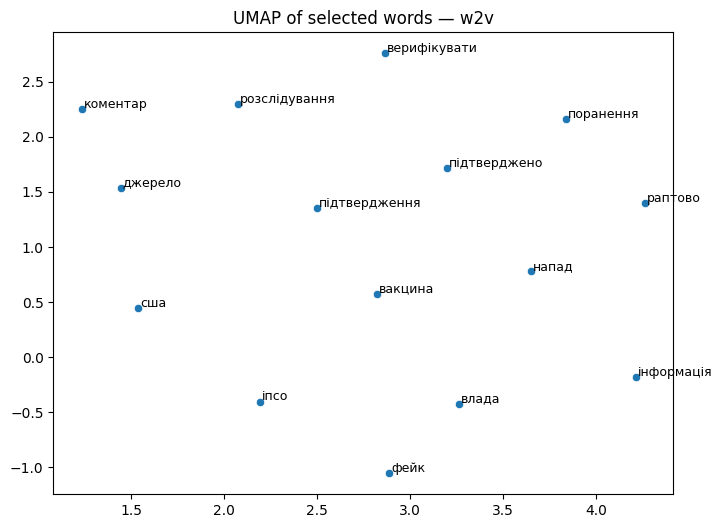

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  if self.n_jobs != 1 and self.random_state is not None:


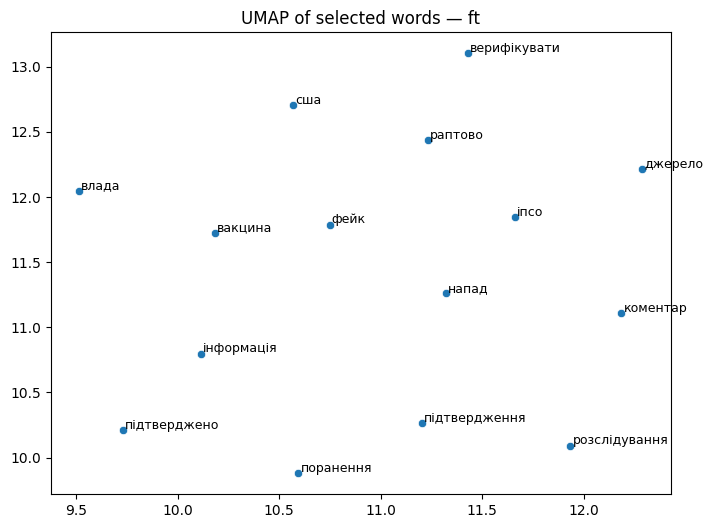

In [39]:
# Візуалізація вибраних слів у 2D (UMAP)
selected_words = list(set(checked_words + domain_terms))[:100]
vectors = []
labels = []
models = {"w2v": w2v_model, "ft": ft_model}

for mname, model in models.items():
    vecs = []
    labs = []
    for w in selected_words:
        try:
            vecs.append(model.wv[w])
            labs.append(w)
        except Exception:
            # skip OOV for Word2Vec
            continue
    if len(vecs) == 0:
        continue
    reducer = umap.UMAP(n_neighbors=10, min_dist=0.3, random_state=42)
    emb = reducer.fit_transform(np.array(vecs))
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=emb[:,0], y=emb[:,1])
    for i, lab in enumerate(labs):
        plt.text(emb[i,0]+0.01, emb[i,1]+0.01, lab, fontsize=9)
    plt.title(f"UMAP of selected words — {mname}")
    plt.show()

In [40]:
def write_embedding_notes(path="/content/embedding_notes_lab9.md"):
    with open(path, "w", encoding="utf-8") as f:
        f.write("# embedding_notes_lab9\n\n")
        f.write("**Corpus**: Ukrainian news (processed_v2.csv)\n\n")
        f.write("**Models trained**: Word2Vec, FastText\n\n")
        f.write("**Parameters**:\n")
        f.write(f"- Word2Vec: {w2v_params}\n")
        f.write(f"- FastText: {ft_params}\n\n")
        f.write("**10 words for nearest neighbors**:\n")
        f.write(", ".join(control_words) + "\n\n")
        f.write("**5 domain terms**:\n")
        f.write(", ".join(domain_terms) + "\n\n")
        f.write("**5 cases (auto-suggested verdicts)**:\n")
        for c, w2v_nei, ft_nei, verdict, note in case_results:
            f.write(f"- {c}: {verdict}; notes: {note}\n")
    print("Wrote", path)

def write_audit_summary(path="/content/audit_summary_lab9.md"):
    with open(path, "w", encoding="utf-8") as f:
        f.write("# audit_summary_lab9\n\n")
        f.write(f"Corpus size (labeled): {len(df)} documents\n\n")
        f.write("Models trained: Word2Vec, FastText\n\n")
        f.write("Strongest nearest neighbor examples (pick 2-3 manually after inspection):\n")
        f.write("- TODO: fill after manual check\n\n")
        f.write("Weakest examples (pick 2-3):\n")
        f.write("- TODO: fill after manual check\n\n")
        f.write("Where FastText won: likely OOV/morphological cases\n\n")
        f.write("Recommendation: ... (fill after manual inspection)\n")
    print("Wrote", path)

write_embedding_notes()
write_audit_summary()
save_results_csv("/content/embeddings_neighbors_summary.csv")

Wrote /content/embedding_notes_lab9.md
Wrote /content/audit_summary_lab9.md
Saved summary to /content/embeddings_neighbors_summary.csv
